In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [1]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize # for ensemble weight optimization
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LassoCV, LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [2]:
# download LightGBM package
!pip install lightgbm

In [3]:
# download catboost package
!pip install catboost

In [4]:
# LGBM & catboost dependencies
import lightgbm as lgbm
from catboost import CatBoostRegressor
#from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [5]:
# function for model evalaution in both log-price 'units' as well as natural units (USD dollar) 
def evaluate_model(y_true, y_pred_log):

    # TRUE VALUES IN LOG SPACE
    y_true_log = np.log1p(y_true)

    # BACK TRANSFORM PREDICTIONS
    y_pred = np.expm1(y_pred_log)

    # --- METRICS IN LOG SPACE ---
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    mape_log = mean_absolute_percentage_error(y_true_log, y_pred_log)

    # --- METRICS IN PRICE SPACE ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print("------ LOG METRICS ------")
    print("RMSE_log:", rmse_log)
    print("MAE_log:", mae_log)
    print("R2_log:", r2_log)
    print("MAPE_log:", mape_log)

    print("\n------ PRICE METRICS ($) ------")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("MAPE:", mape)

    return

In [38]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'candidate_count', 'location_filled', 'date', 'usd', 'gbp', 'eur', 'lot','maker_name','role', 'Day', 'gbp_usd_y']
train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']


In [10]:
X_train.columns

Index(['sale_date', 'maker_id', 'type', 'city_maker', 'auction_house',
       'bold_currency', 'Year', 'Month', 'Day', 'cpi_usd', 'cpi_gbp',
       'cpi_eur', 'gbp_usd_x', 'eur_usd', 'SP500_real', 'SP500_30d_ret',
       'SP500_90d_ret', 'SP500_252d_ret', 'SP500_vol_30d', 'SP500_vol_90d',
       'SP500_vol_252d', 'SP500_ma50', 'SP500_ma200', 'SP500_trend_ratio',
       'gbp_usd_y', 'gbp_90d_change', 'gbp_vol_30d', '10y_yield_pc',
       '10y_yield_90d_change', 'MCI', 'real_price_gold', 'country_iso1',
       'admin1_name', 'admin2_name', 'maker_last_name', 'birth_cent'],
      dtype='object')

In [24]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lowcard__type_Bass
lowcard__type_Bass Bow
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__bold_currency_usd
num__SP500_30d_ret
num__gbp_vol_30d
num__gbp_usd_x
num__Year
num__SP500_trend_ratio
num__cpi_usd
num__SP500_vol_30d
num__SP500_ma200
num__Month


In [37]:
X_train.Day

0         1
1        13
2        14
3        12
4         1
         ..
33617     8
33618    22
33619    19
33620     9
33621    22
Name: Day, Length: 33622, dtype: int64

In [46]:
X_train.sale_date=pd.to_datetime(X_train.sale_date)
X_valid.sale_date=pd.to_datetime(X_valid.sale_date)

C:\Users\Pierre\AppData\Local\Temp\ipykernel_23712\432308552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.sale_date=pd.to_datetime(X_train.sale_date)
C:\Users\Pierre\AppData\Local\Temp\ipykernel_23712\432308552.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid.sale_date=pd.to_datetime(X_valid.sale_date)


In [43]:
X_train.sale_date

0       2022-12-01
1       1990-06-13
2       2010-06-14
3       1986-11-12
4       1994-11-01
           ...    
33617   2024-10-08
33618   1986-05-22
33619   1997-03-19
33620   1987-06-09
33621   1990-11-22
Name: sale_date, Length: 33622, dtype: datetime64[ns]

In [44]:
LogColumns = ['real_price_gold', 'SP500_real']
LowCardCols = ["type", "bold_currency","Month"]
HighCardCols = ["maker_id", "city_maker", "auction_house", "country_iso1", "admin1_name", "admin2_name", "maker_last_name"]

In [47]:
from catboost import Pool

y_train_log = np.log1p(Y_train.squeeze())
y_valid_log = np.log1p(Y_valid.squeeze())

X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()

for col in LogColumns:
    X_train_cat[col] = np.log1p(X_train_cat[col])
    X_valid_cat[col] = np.log1p(X_valid_cat[col])

cat_cols = list(dict.fromkeys(LowCardCols + HighCardCols))

for col in cat_cols:
    X_train_cat[col] = X_train_cat[col].fillna("__MISSING__").astype(str)
    X_valid_cat[col] = X_valid_cat[col].fillna("__MISSING__").astype(str)

train_pool = Pool(
    X_train_cat,
    y_train_log,
    cat_features=cat_cols
)

valid_pool = Pool(
    X_valid_cat,
    y_valid_log,
    cat_features=cat_cols
)

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=0,
    allow_writing_files=False
)

param_dist = {
    "iterations": [1000, 2000],
    "learning_rate": [0.02, 0.05],
    "depth": [6, 8],
    "l2_leaf_reg": [3, 10, 20]
}

search_result = cat_model.randomized_search(
    param_distributions=param_dist,
    X=train_pool,
    cv=3,
    n_iter=8,
    partition_random_seed=42,
    calc_cv_statistics=True,
    search_by_train_test_split=False,
    refit=True,
    verbose=True
)

print("Best CatBoost params:", search_result["params"])

cat_pred = cat_model.predict(valid_pool)
evaluate_model(Y_valid, cat_pred)

Training on fold [0/3]

bestTest = 0.6396065276
bestIteration = 997

Training on fold [1/3]

bestTest = 0.6555496163
bestIteration = 999

Training on fold [2/3]

bestTest = 0.6528127605
bestIteration = 999

0:	loss: 0.6493267	best: 0.6493267 (0)	total: 2m 26s	remaining: 17m 6s
Training on fold [0/3]

bestTest = 0.6462169535
bestIteration = 999

Training on fold [1/3]

bestTest = 0.6626144924
bestIteration = 999

Training on fold [2/3]

bestTest = 0.6617100099
bestIteration = 999

1:	loss: 0.6568472	best: 0.6493267 (0)	total: 4m 50s	remaining: 14m 30s
Training on fold [0/3]

bestTest = 0.6331857464
bestIteration = 998

Training on fold [1/3]

bestTest = 0.6481476283
bestIteration = 999

Training on fold [2/3]

bestTest = 0.6478372645
bestIteration = 998

2:	loss: 0.6430693	best: 0.6430693 (2)	total: 8m 48s	remaining: 14m 41s
Training on fold [0/3]

bestTest = 0.6522082814
bestIteration = 999

Training on fold [1/3]

bestTest = 0.6653717895
bestIteration = 999

Training on fold [2/3]

be

SyntaxError: invalid non-printable character U+00A0 (4035533316.py, line 76)

# Model 4: CatBoost

In [37]:
y_train_log = np.log1p(Y_train.squeeze())
y_valid_log = np.log1p(Y_valid.squeeze())

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0)

pipeline_cat = Pipeline([("preprocessor", preprocessor), ("model", cat_model)])

'''param_dist = {
    "model__iterations": [2000,3000,4000], #best was 2000
    "model__learning_rate": [0.01,0.02,0.03], #best was 0.03
    "model__depth": [10, 12, 15], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}'''
param_dist = {
    "model__iterations": [2000], #best was 2000
    "model__learning_rate": [0.03], #best was 0.03
    "model__depth": [10], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}

search_cat = RandomizedSearchCV(
    pipeline_cat,
    param_distributions=param_dist,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [33]:
search_cat.fit(X_train, y_train_log)

best_cat = search_cat.best_estimator_
print("Best CatBoost params:", search_cat.best_params_)

NameError: name 'search_cat' is not defined

In [32]:
y_pred_log_cat = best_cat.predict(X_valid)

evaluate_model(Y_valid.squeeze(), y_pred_log_cat)

NameError: name 'best_cat' is not defined

# Model(s) 5: Ensemble Method
In this section we will combine (in various ways) the predictions of the three performant model (Random Forest, LGBM, CatBoost) in order to determine whether a combination of the models performs better than each one alone.

In [40]:
# stack all the predictions that ought be used in the ensemble
X_ensemble = np.column_stack([
    forest_pred,
    y_pred_log_lgbm,
    y_pred_log_cat
])

## Naive Ensemble

In [41]:
y_pred_avg = X_ensemble.mean(axis=1)

In [42]:
evaluate_model(Y_valid, y_pred_avg)

------ LOG METRICS ------
RMSE_log: 0.5919821070684487
MAE_log: 0.4482370124800803
R2_log: 0.8091307166508869
MAPE_log: 0.052121592447829816

------ PRICE METRICS ($) ------
RMSE: 82403.37908974005
MAE: 11794.036863520067
R2: 0.5658553384540379
MAPE: 0.5646448606500584


## Weighted Ensemble
We find the optimal ensemble weights via optimization with a RMSE loss for weighting the models linearly, which is implemented through an additional Ridge Regression. This means the ensemble prediction is a omptimized linear combination of the 3 input model predictions. 

In [43]:
def rmse_loss(weights):
    weights = weights / weights.sum()  # normalize weights, such that they sum to 1
    y_pred = np.dot(X_ensemble, weights)
    return np.sqrt(mean_squared_error(y_valid_log, y_pred))

# initial equal weights
init_weights = np.array([1/3, 1/3, 1/3])

# constraint: weights sum to 1
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

# bounds: weights between 0 and 1
bounds = [(0, 1)] * 3

result = minimize(rmse_loss, init_weights, bounds=bounds, constraints=constraints) # scipy numerical optimizer

optimal_weights = result.x / result.x.sum()
print("Optimal weights:", optimal_weights)

Optimal weights: [0.02001516 0.37105589 0.60892895]


In [44]:
meta_model = Ridge(alpha=1)
meta_model.fit(X_ensemble, y_valid_log)

y_pred_stacked = meta_model.predict(X_ensemble)

print("Stacking coefficients:", meta_model.coef_)

Stacking coefficients: [0.02561564 0.3731472  0.61383278]


In [48]:
y_pred_stacked

NameError: name 'y_pred_stacked' is not defined

In [45]:
evaluate_model(Y_valid, y_pred_stacked)

------ LOG METRICS ------
RMSE_log: 0.5884424617022938
MAE_log: 0.44621828716249207
R2_log: 0.8114064264275422
MAPE_log: 0.05188117335873086

------ PRICE METRICS ($) ------
RMSE: 84541.45276895282
MAE: 11749.662581048666
R2: 0.5430340547880419
MAPE: 0.5606354471370183


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def error_analysis_report(
    X,
    y_true_raw,
    y_pred_log,
    location_col="location_filled",
    type_col="type",
    country_col="country_iso1",
    price_outlier_q=0.99,
    error_outlier_q=0.95,
    min_group_size=20,
    top_n_countries=15,
    top_n_worst_rows=25
):
    """
    Analyse d'erreur pour un modèle entraîné sur log1p(price).
    """

    X = X.copy().reset_index(drop=True)
    y_true_raw = pd.Series(np.asarray(y_true_raw).reshape(-1), name="y_true_raw").reset_index(drop=True)
    y_pred_log = pd.Series(np.asarray(y_pred_log).reshape(-1), name="y_pred_log").reset_index(drop=True)

    if not (len(X) == len(y_true_raw) == len(y_pred_log)):
        raise ValueError("X, y_true_raw, et y_pred_log doivent avoir la même longueur.")

    df = X.copy()
    df["y_true_raw"] = y_true_raw
    df["y_true_log"] = np.log1p(y_true_raw.clip(lower=0))
    df["y_pred_log"] = y_pred_log
    df["y_pred_raw"] = np.expm1(y_pred_log)

    # Calcul des erreurs
    df["error_raw"] = df["y_pred_raw"] - df["y_true_raw"]
    df["abs_error_raw"] = df["error_raw"].abs()

    denom = np.maximum(df["y_true_raw"].to_numpy(), 1.0)
    df["pct_error"] = 100.0 * df["error_raw"] / denom
    df["abs_pct_error"] = df["pct_error"].abs()

    df["error_log"] = df["y_pred_log"] - df["y_true_log"]
    df["abs_error_log"] = df["error_log"].abs()

    # Détection des outliers
    price_cut = df["y_true_raw"].quantile(price_outlier_q)
    err_cut = df["abs_error_log"].quantile(error_outlier_q)

    df["price_outlier"] = df["y_true_raw"] >= price_cut
    df["error_outlier"] = df["abs_error_log"] >= err_cut

    df["outlier_bucket"] = np.select(
        [
            df["price_outlier"] & df["error_outlier"],
            df["price_outlier"] & ~df["error_outlier"],
            ~df["price_outlier"] & df["error_outlier"],
        ],
        [
            "price_and_error_outlier",
            "price_outlier_only",
            "error_outlier_only",
        ],
        default="neither"
    )

    # Fonction interne pour calculer les métriques par groupe
    def summarize(g):
        return pd.Series({
            "count": len(g),
            "rmse_raw": np.sqrt(np.mean(g["error_raw"] ** 2)),
            "mae_raw": np.mean(g["abs_error_raw"]),
            "rmse_log": np.sqrt(np.mean(g["error_log"] ** 2)),
            "mae_log": np.mean(g["abs_error_log"]),
            "mean_abs_pct_error": np.mean(g["abs_pct_error"]),
            "median_abs_pct_error": np.median(g["abs_pct_error"]),
            "mean_bias_raw": np.mean(g["error_raw"]),
            "mean_bias_log": np.mean(g["error_log"]),
            "share_abs_pct_over_25": np.mean(g["abs_pct_error"] > 25),
            "share_abs_pct_over_50": np.mean(g["abs_pct_error"] > 50),
        })

    overall_summary = summarize(df).to_frame().T

    # Résumé par localisation
    if location_col in df.columns:
        location_summary = (
            df.groupby(location_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
    else:
        location_summary = None
        print(f"Colonne '{location_col}' non trouvée ; analyse de localisation ignorée.")

    # Résumé des outliers
    price_outlier_summary = df.groupby("price_outlier", dropna=False).apply(summarize).reset_index()
    error_outlier_summary = df.groupby("error_outlier", dropna=False).apply(summarize).reset_index()
    outlier_bucket_summary = (
        df.groupby("outlier_bucket", dropna=False)
        .apply(summarize)
        .reset_index()
        .sort_values("count", ascending=False)
    )

    # Résumé par type
    if type_col in df.columns:
        type_summary = (
            df.groupby(type_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
        type_summary = type_summary[type_summary["count"] >= min_group_size].copy()
    else:
        type_summary = None
        print(f"Colonne '{type_col}' non trouvée ; analyse par type ignorée.")

    # Résumé par pays
    if country_col in df.columns:
        country_summary = (
            df.groupby(country_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
        country_summary = country_summary[country_summary["count"] >= min_group_size].copy()
        country_summary = country_summary.head(top_n_countries).copy()
    else:
        country_summary = None
        print(f"Colonne '{country_col}' non trouvée ; analyse par pays ignorée.")

    # Extraction des pires lignes pour inspection
    inspect_cols = [c for c in [type_col, country_col, location_col, "maker_name", "maker_last_name", "sale_date"] if c in df.columns]
    worst_rows = (
        df[inspect_cols + [
            "y_true_raw", "y_pred_raw", "error_raw", "abs_error_raw",
            "pct_error", "abs_pct_error", "y_true_log", "y_pred_log",
            "error_log", "abs_error_log", "price_outlier", "error_outlier", "outlier_bucket"
        ]]
        .sort_values("abs_error_log", ascending=False)
        .head(top_n_worst_rows)
        .copy()
    )

    # ---------- Visualisation ----------
    def plot_bar(summary_df, group_col, metric_col, title):
        if summary_df is None or summary_df.empty:
            return
        plot_df = summary_df.sort_values(metric_col, ascending=False).copy()
        labels = plot_df[group_col].astype(str)

        plt.figure(figsize=(max(8, 0.55 * len(plot_df) + 2), 5))
        plt.bar(labels, plot_df[metric_col])
        plt.title(title)
        plt.ylabel(metric_col)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_boolean_group(summary_df, group_col, metric_col, title):
        if summary_df is None or summary_df.empty:
            return
        labels = summary_df[group_col].astype(str)

        plt.figure(figsize=(6, 4))
        plt.bar(labels, summary_df[metric_col])
        plt.title(title)
        plt.ylabel(metric_col)
        plt.tight_layout()
        plt.show()

    # Affichage des graphiques
    if location_summary is not None:
        plot_boolean_group(location_summary, location_col, "median_abs_pct_error", f"Median absolute % error by {location_col}")
        plot_boolean_group(location_summary, location_col, "rmse_log", f"Log-RMSE by {location_col}")

    plot_boolean_group(price_outlier_summary, "price_outlier", "median_abs_pct_error", "Median absolute % error: price outliers vs non-outliers")
    plot_boolean_group(error_outlier_summary, "error_outlier", "median_abs_pct_error", "Median absolute % error: error outliers vs non-outliers")

    if type_summary is not None:
        plot_bar(type_summary, type_col, "median_abs_pct_error", f"Median absolute % error by {type_col}")

    if country_summary is not None:
        plot_bar(country_summary, country_col, "median_abs_pct_error", f"Median absolute % error by {country_col} (top {top_n_countries} by count)")

    results = {
        "row_level_df": df,
        "overall_summary": overall_summary,
        "location_summary": location_summary,
        "price_outlier_summary": price_outlier_summary,
        "error_outlier_summary": error_outlier_summary,
        "outlier_bucket_summary": outlier_bucket_summary,
        "type_summary": type_summary,
        "country_summary": country_summary,
        "worst_rows": worst_rows,
        "price_outlier_cutoff": price_cut,
        "error_outlier_cutoff_abs_log_error": err_cut,
    }

    return results

In [52]:
train.columns

Index(['sale_date', 'maker_id', 'type', 'city_maker', 'auction_house',
       'bold_currency', 'Year', 'Month', 'cpi_usd', 'cpi_gbp', 'cpi_eur',
       'gbp_usd_x', 'eur_usd', 'price_usd_real', 'SP500_real', 'SP500_30d_ret',
       'SP500_90d_ret', 'SP500_252d_ret', 'SP500_vol_30d', 'SP500_vol_90d',
       'SP500_vol_252d', 'SP500_ma50', 'SP500_ma200', 'SP500_trend_ratio',
       'gbp_usd_y', 'gbp_90d_change', 'gbp_vol_30d', '10y_yield_pc',
       '10y_yield_90d_change', 'MCI', 'real_price_gold', 'country_iso1',
       'admin1_name', 'admin2_name', 'maker_last_name', 'birth_cent'],
      dtype='object')

C:\Users\Pierre\AppData\Local\Temp\ipykernel_23712\367336827.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize)
C:\Users\Pierre\AppData\Local\Temp\ipykernel_23712\367336827.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  price_outlier_summary = df.groupby("price_outlier", dropna=False).apply(summarize).reset_index()
C:\Users\Pierre\AppData\Local\Temp\ipykernel_23712\367336827.py:99:

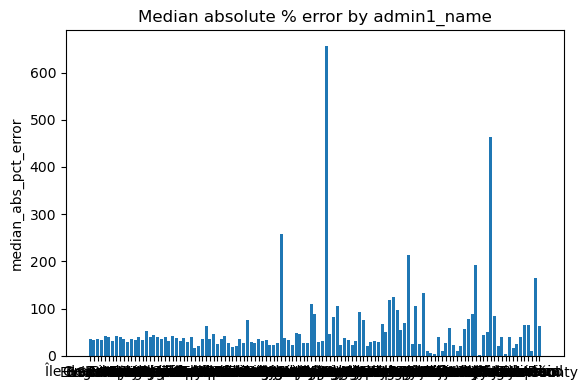

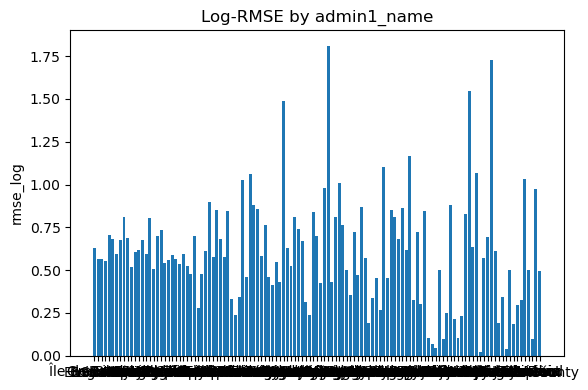

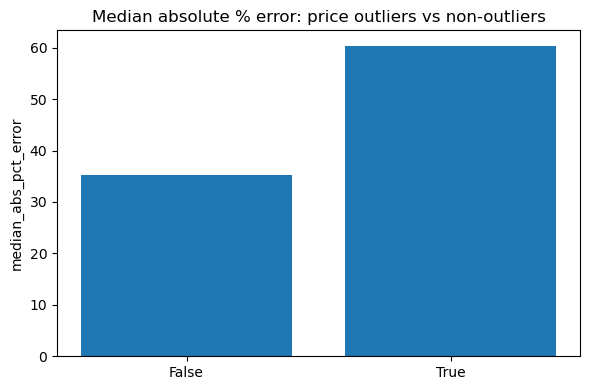

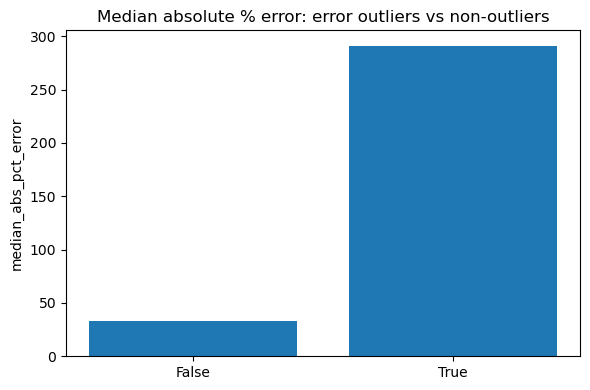

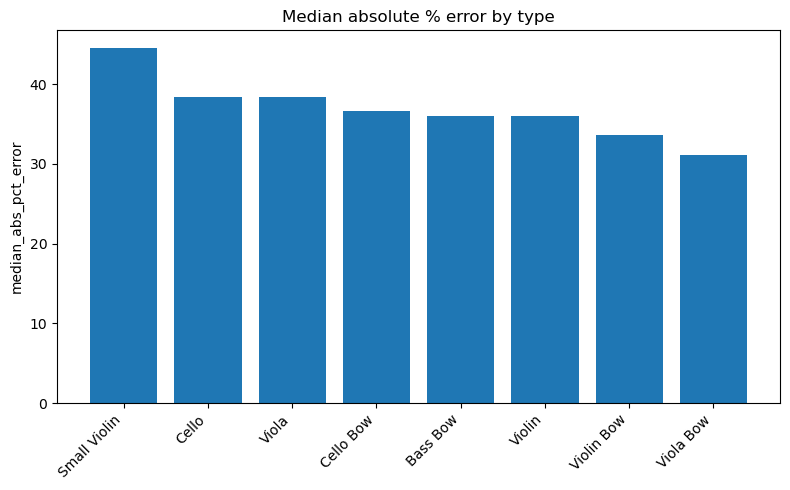

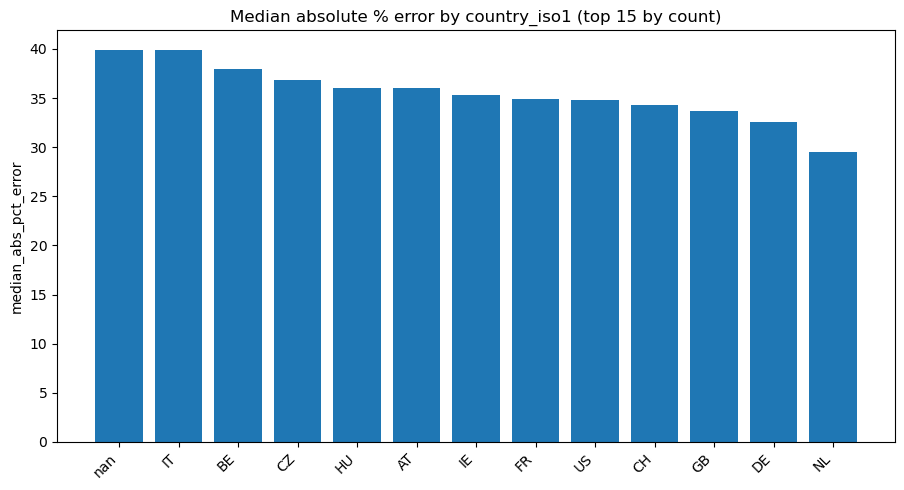

In [53]:


# 2. Appeler la fonction
results = error_analysis_report(
    X=X_valid,
    y_true_raw=Y_valid,
    y_pred_log=cat_pred,
    location_col="admin1_name", # Assure-toi que cette colonne existe dans X_test
    type_col="type",
    country_col="country_iso1"
)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Fonction modifiée pour inclure le top N et l'ordre décroissant
def plot_bar_improved(summary_df, group_col, metric_col, title, top_n=None):
    if summary_df is None or summary_df.empty:
        return
    
    # Copie pour ne pas modifier l'original
    plot_df = summary_df.copy()
    
    # Trier par métrique pour placer les pires erreurs en premier
    plot_df = plot_df.sort_values(metric_col, ascending=False)
    
    # Sélectionner le top N (par exemple 10)
    if top_n is not None:
        plot_df = plot_df.head(top_n)
        if title:
            title = f"{title} (Top {top_n})"
    
    labels = plot_df[group_col].astype(str)
    
    # Ajuster la taille de la figure en fonction du nombre de barres
    plt.figure(figsize=(max(8, 0.6 * len(plot_df)), 5))
    
    # Créer les barres
    bars = plt.bar(labels, plot_df[metric_col])
    
    plt.title(title)
    plt.ylabel(metric_col)
    
    # Améliorer les étiquettes de l'axe X
    plt.xticks(rotation=45, ha="right")
    
    # Optionnel : ajouter les valeurs au-dessus des barres
    # pour une lecture plus précise
    # for bar in bars:
    #     height = bar.get_height()
    #     plt.text(bar.get_x() + bar.get_width() / 2, height,
    #              f'{height:.1f}',
    #              ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Exemple d'appel pour votre cas spécifique
# Supposons que 'region_summary' contient vos résultats de groupby par admin1_name

# Au lieu d'appeler votre ancienne fonction, appelez la nouvelle :
# plot_bar_improved(
#     region_summary,       # Votre DataFrame de résumé
#     'admin1_name',        # La colonne de groupe
#     'median_abs_pct_error', # La métrique
#     'Erreur médiane par région', # Le titre de base
#     top_n=10              # Paramètre ajouté
# )